# Sentiment Analysis of Twitter Posts
<!-- Notebook name goes here -->
<center><b>Notebook: Model Evaluations and Conclusions</b></center>
<br>

**By**: Stephen Borja, Justin Ching, Erin Chua, and Zhean Ganituen.

**Dataset**: Hussein, S. (2021). Twitter Sentiments Dataset [Dataset]. Mendeley. https://doi.org/10.17632/Z9ZW7NT5H2.1

**Motivation**: Every minute, social media users generate a large influx of textual data on live events. Performing sentiment analysis on this data provides a real-time view of public perception, enabling quick insights into the general population’s opinions and reactions.

**Goal**: By the end of the project, our goal is to create and compare supervised learning algorithms for sentiment analysis.

# **1. Project Setup**

We first import the relevant libraries for the three models.


In [23]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as fun
from torch.utils.data import DataLoader

# General Imports
import sys, os
import joblib as jb
import numpy as np

# Analysis Imports
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../lib"))

from anal_ysis_tools import (
    report_classification_performance
)
from barn.trainer import validate
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Select device (using CUDA if possible)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


# **2. Data Setup**

Now, we run the data processing pipeline. The below cell's sole purpose is to run the `data.ipynb` notebook, which runs everything related to data cleaning and data pre-processing.

In [24]:
import IPython.core.page
import builtins
from IPython.utils.capture import capture_output

pager = IPython.core.page.page
helper = builtins.help

IPython.core.page.page = lambda *args, **kwargs: None
builtins.help = lambda *args, **kwargs: None

try:
    with capture_output():
        %run data.ipynb
finally:
    IPython.core.page.page = pager
    builtins.help = helper

print("Data Setup is DONE")

# Tests
assert X.shape == (162_801, 29318), "Feature matrix shape is wrong; expected (162_801, 29318)"
assert y.shape == (162_801,), "Labels shape is wrong; expected (162_801,)"

assert X_train.shape == (113_960, 29_318), "Train shape is wrong; expected (113_960, 29318)"
assert Xb_train.shape == (74_565, 29_318), "Train shape is wrong; expected (74_292, 29318)"
assert X_val.shape == (24_420, 29_318), "Validation shape is wrong; expected (24_420, 29318)"
assert X_test.shape == (24_421, 29_318), "Test shape is wrong; expected (24_421, 29318)"

assert y_train.shape == (113_960,), "Train labels shape is wrong; expected (113_960,)"
assert yb_train.shape == (74_565,), "Train labels shape is wrong; expected (74_292,)"
assert y_val.shape == (24_420,), "Validation labels shape is wrong; expected (24_420,)"
assert y_test.shape == (24_421,), "Test labels shape is wrong; expected (24_421,)"
print("All tests passed.")

Data Setup is DONE
All tests passed.


For our neural network, we prepare the dataset to be PyTorch-compatible.

Because our labels in `y_train` are `-1`, `0`, and `1`, they are incompatible with PyTorch which requires class labels to be non-negative integers. TorchableSet maps them to non-negative integers so that PyTorch can handle them.

TorchableSet also ensures that the features (`X_train`) are stored in a sparse matrix and the labels (`y_train`) are in a NumPy array for easier handling.

In [25]:
from barn.data_preparer import TorchableSet

TRAIN_IMB = TorchableSet(X_train, y_train)
TRAIN_BAL = TorchableSet(Xb_train, yb_train)
TEST = TorchableSet(X_test, y_test)
VAL = TorchableSet(X_val, y_val)

We also need to set up our Multilayer Perceptron (MLP) architecture. We'll need this to create and define MLP models.

In [26]:
class MyLittlePony(nn.Module):
    def __init__(self, vocab_size, neurons_in_hidden, n_hidden_layers, dropout):
        """
        Architecture definition for the neural network.

        # Parameters
        * vocab_size: number of words in the dataset, this is the number of neurons in the input layer
        * neurons_in_hidden: number of neurons in the hidden layers
        * n_hidden_layers: number of hidden layers
        * dropout: dropout value

        # Remarks
        * Documenation is provided for each layer. Notation is as follows
            * n is the number of neurons
            * a is the activation function
        * Number of neurons in the output layer is a constant 3 (one for each sentiment in the dataset).
        """
        super().__init__()
        # INPUT LAYER
        # -----------
        # n  :: vocab_size
        # a  :: ReLU
        layers = [
            nn.Linear(vocab_size, neurons_in_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]

        # HIDDEN LAYER
        # ------------
        # NN :: hidden_dim
        # A  :: ReLU
        for _ in range(n_hidden_layers - 1):
            layers.append(nn.Linear(neurons_in_hidden, neurons_in_hidden))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))

        # OUTPUT LAYER
        # ------------
        # n  :: 3    (for each sentiment)
        # a  :: none (left as XΘ)
        layers.append(nn.Linear(neurons_in_hidden, 3))

        self.model = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        """
        Kaiming He initialization
        """
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.model(x)

    def predict_proba(self, X):
        self.eval()
        device = next(self.parameters()).device
        with torch.no_grad():
            X = X.to(device)
            logits = self(X)

            probabilities = torch.softmax(logits, dim=1)
            return probabilities.cpu().numpy()

This next function is to get the predictions and true labels. This is for MLP's results to be compatible with our performance reporting function.

In [27]:
def get_predictions(model, val_loader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            all_labels.extend(labels.cpu().tolist())
            all_preds.extend(predicted.cpu().tolist())

    return np.array(all_preds), np.array(all_labels)

Now that we have everything set up, we can move on to the next section.

# **3. Comparison of Models**

In this section, we'll be evaluating and comparing the results of our three selected models:

1. **Multinomial Naive Bayes (MNB)**
2. **Multinomial Logistic Regression (MLR)**
3. **Multilayer Perceptron (MLP)**

For easier reading, we will be calling *Multinomial Naive Bayes* as **Bayes** and *Multinomial Logistic Regression* as **LogReg**. *Multilayer Perceptron* will stay as **MLP**.

## **3.1 Comparison of Performance on Imbalanced Data**

Our three classes have a moderate imbalance, with Class `1` taking up **44%**, Class `0` taking up **33%**, and Class `-1` taking up **22%** of the data. We'll be testing our models on imbalanced data first to see if balancing will make a difference.

We need to first get our already-trained models from the folder we saved them in. They are all stored in the `models` folder and categorized into `imbalanced`, `balanced`, and `tuned`.

We'll start with the **imbalanced data** using **default hyperparameters**.

In [28]:
mnb_imbalanced = jb.load('models/imbalanced/mnb_imbalanced.pkl')
mlr_imbalanced = jb.load('models/imbalanced/mlr_imbalanced.pkl')

neurons_in_hidden = 32
n_hidden_layers = 2
dropout = 0.2
batch_size = 32

mlp_imbalanced = MyLittlePony(
    vocab_size=TRAIN_IMB.vocab_size,
    neurons_in_hidden=neurons_in_hidden,
    n_hidden_layers=n_hidden_layers,
    dropout=dropout
).to(DEVICE)
mlp_imbalanced.load_state_dict(torch.load('models/imbalanced/mlp_imbalanced.pth'))
mlp_imbalanced.eval()

print("Models loaded")

Models loaded


Next, let's run each of them on the test data.

In [29]:
y_pred_mnb_imbal = mnb_imbalanced.predict(X_test)
y_pred_mlr_imbal = mlr_imbalanced.predict(X_test)

# MLP
test_loader = DataLoader(TEST, batch_size=batch_size, shuffle=False)
y_pred, y_true = get_predictions(mlp_imbalanced, test_loader, DEVICE)

y_pred_mlp_imbal = y_pred - 1  # labels to -1, 0, 1

Now, we'll get the results of these models. For easier reading, we have omitted "Multinomial" from their names.

In [30]:
all_predictions_imbal = {
    "Multinomial Naive Bayes (MNB)": y_pred_mnb_imbal,
    "Multinomial Logistic Regression (MLR)": y_pred_mlr_imbal,
    "Multilayer Perceptron (MLP)": y_pred_mlp_imbal
}

print("Accuracies on Imbalanced Data with Default Hyperparameters:")
for name, prediction in all_predictions_imbal.items():
    acc = accuracy_score(y_test, prediction)
    f1 = f1_score(y_test, prediction, average="macro")
    print(f"{name:37} Accuracy: {acc:.4f} | F1 score: {f1:.4f}")

Accuracies on Imbalanced Data with Default Hyperparameters:
Multinomial Naive Bayes (MNB)         Accuracy: 0.7151 | F1 score: 0.7024
Multinomial Logistic Regression (MLR) Accuracy: 0.8441 | F1 score: 0.8346
Multilayer Perceptron (MLP)           Accuracy: 0.8344 | F1 score: 0.8255


We can see here that **LogReg** has both the **highest accuracy and F1 score**, with around 84.4% and 83.5% respectively. It has quite a great accuracy considering it was trained on an imbalanced dataset, and the F1 score suggests that its precision and recall are good, meaning that the model is correctly identifying even the less represented classes.

**MLP** comes in **2nd**, with both its accuracy and F1 score results only being about 1% less than LogReg's, showing that it performs similarly.

**Bayes** performs the **worst** with an accuracy of **71.5%** and an F1 score of **70.2%**. While this performance is acceptable, it is **much worse** compared to LogReg and MLP.

Let's check the precision and recall of the models.

In [31]:
for name, prediction in all_predictions_imbal.items():
    for separator in range(60):
        print("-", end='')
    print(f"\n{name}", end='')
    report_classification_performance(model=None, y_pred=prediction, y_test=y_test)

------------------------------------------------------------
Multinomial Naive Bayes (MNB)
Classification Report:

              precision    recall  f1-score   support

          -1     0.5837    0.6756    0.6263      5326
           0     0.7855    0.6811    0.7296      8259
           1     0.7426    0.7604    0.7514     10836

    accuracy                         0.7151     24421
   macro avg     0.7039    0.7057    0.7024     24421
weighted avg     0.7225    0.7151    0.7167     24421

------------------------------------------------------------
Multinomial Logistic Regression (MLR)
Classification Report:

              precision    recall  f1-score   support

          -1     0.8133    0.7550    0.7831      5326
           0     0.8195    0.9075    0.8612      8259
           1     0.8806    0.8395    0.8595     10836

    accuracy                         0.8441     24421
   macro avg     0.8378    0.8340    0.8346     24421
weighted avg     0.8452    0.8441    0.8434     24421



Let's also check out their confusion matrices for more information.

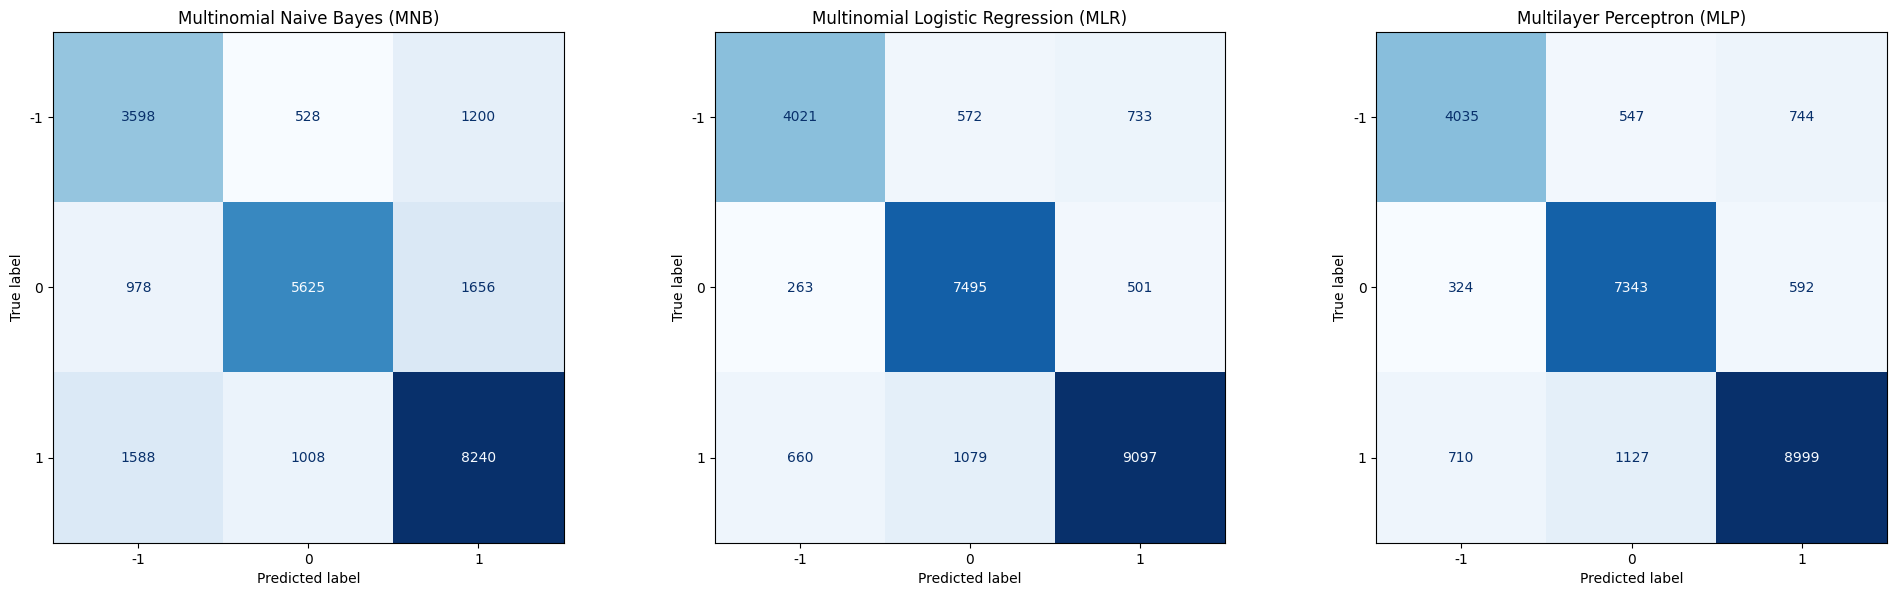

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, prediction) in enumerate(all_predictions_imbal.items()):
    cm_values = confusion_matrix(y_test, prediction)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_values, display_labels=[-1, 0, 1])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)

    axes[i].set_title(name)

plt.tight_layout()
plt.show()

Now, we can see the actual occurrences per class. Class `-1` has **5326** occurrences, Class `0` has **8259** occurrences, and Class `1` has **10836** occurrences. Let's compare the results for each model per class.

### **Recall and Precision**
### | Class `-1` |
#### **- Bayes**
It seems that the recall of Bayes **isn't great**. It has a **67.6%** recall, meaning that it misses **32.4%** of actual Class `-1` occurrences.

Its precision is also **much lower than the other models'**, with a **58.4%** precision, meaning that **41.6%** of the predictions as Class `-1` are actually from other classes.

#### **- LogReg**
The performance for LogReg is noticeably **much better than Bayes** in **both recall and precision**, with a **75.5%** recall and an **81.3%** precision.

#### **- MLP**
MLP **performs similarly to LogReg**, albeit with a near **2% lower** precision and a **very slightly higher** recall.


### | Class `0` |
#### **- Bayes**
The recall for Class `0` is **similar** to its Class `-1` recall, only being about **0.5% higher**, but its precision is **significantly higher**, having **20.2% more** precision.

#### **- LogReg**
The recall is **significantly higher** for Class `0` compared to Bayes, being **22.7% higher**, although its precision only increased by a bit.

Noticeably, its recall is also **15.3% higher** than its own Class `-1` recall. This means that it "captures" most of the Class `0`s in the test set.

#### **- MLP**
Its performance is **similar to LogReg**'s performance in both recall and precision.


### | Class `1` |
#### **- Bayes**
Its recall is **better** for Class `1` compared to the other two classes, being about **8.2% higher**. Although, its precision is about **4% worse** compared to Class `0`.

#### **- LogReg**
Both its recall and precision are **better** compared to Bayes. Compared to the other two classes, Class `1` has the **highest precision** with **88.1%** precision, but its recall went **lower** compared to Class `0`.

#### **- MLP**
MLP performs **similarly to LogReg** in both recall and precision.

We can also check the models' confidence score for incorrect predictions, which can help us understand their behavior.

E:\Media-Files\Real-Stuff\School\Code-Files\Cloned-Repositories\STINTSY-Order-of-Erin\.venv\Lib\site-packages\sklearn\naive_bayes.py:141: RuntimeWarning: invalid value encountered in subtract
  return jll - xpx.atleast_nd(log_prob_x, ndim=2).T


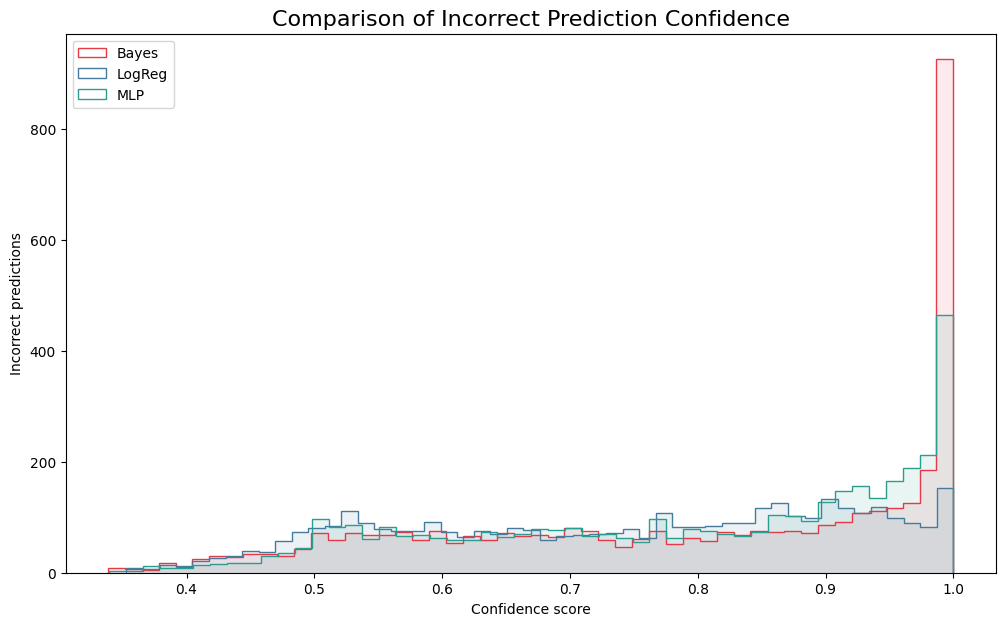

In [33]:
mnb_confidence = mnb_imbalanced.predict_proba(X_test).max(axis=1)[y_pred_mlp_imbal != y_test.values]
mlr_confidence = mlr_imbalanced.predict_proba(X_test).max(axis=1)[y_pred_mlr_imbal != y_test.values]

X_convert = []

for X_batch, _ in test_loader:
    X_convert.append(X_batch)

X_converted = torch.cat(X_convert, dim=0).to(DEVICE)

with torch.no_grad():
    mlp_logits = mlp_imbalanced(X_converted)
    mlp_probs = fun.softmax(mlp_logits, dim=1).cpu().numpy().max(axis=1)
    mlp_confidence = mlp_probs[y_pred_mlp_imbal != y_test.values]

plt.figure(figsize=(12, 7))

# Outline
plt.hist(mnb_confidence, bins=50, histtype='step', label="Bayes", color="#E63946")
plt.hist(mlr_confidence, bins=50, histtype='step', label="LogReg", color="#457B9D")
plt.hist(mlp_confidence, bins=50, histtype='step', label="MLP", color="#2A9D8F")

# Fill
plt.hist(mnb_confidence, bins=50, alpha=0.1, color="#E63946")
plt.hist(mlr_confidence, bins=50, alpha=0.1, color="#457B9D")
plt.hist(mlp_confidence, bins=50, alpha=0.1, color="#2A9D8F")

plt.title("Comparison of Incorrect Prediction Confidence", fontsize=16)
plt.xlabel("Confidence score")
plt.ylabel("Incorrect predictions")
plt.legend(loc='upper left')

plt.show()

In this histogram, we can see that all three models are **negatively skewed**, with Bayes and MLP being the most prominent. There are a lot more incorrect predictions made by Bayes, but all three's trends are the similar, where a **significant amount of incorrect predictions** were made with **100% confidence**. This is bad as it means that the models may have **overfitted** to the training data.

## **Imbalanced Data Insights**

So far, for imbalanced data, **LogReg** performs the best, **MLP** performs the second-best, and **Bayes** performs the worst. Overall, Class `-1` is the most difficult to predict, Class `0` is intermediate, and Class `1` is the easiest across all three models. This performance is probably due to the data imbalance of all three classes.

Next, we'll see how the models perform on a balanced test set.

## **3.2 Comparison of Performance on Balanced Data**

As mentioned in the previous section, the three classes have a moderate imbalance, with Class `1` taking up **44%**, Class `0` taking up **33%**, and Class `-1` taking up **22%** of the data.

Training on imbalanced data trains the model on fewer instances for specific classes, especially if the dataset leans towards a specific class. In this case, Class `1` has the most instances, so training it on the imbalanced train set, the model would learn more of Class `1` than the other classes. So, we'll check if balancing the training set has any improvement on the model's performance.

We'll now work with the **balanced data** still using **default hyperparameters**. We'll be doing the same model-loading process as the previous section.

In [34]:
mnb_balanced = jb.load('models/balanced/mnb_balanced.pkl')
mlr_balanced = jb.load('models/balanced/mlr_balanced.pkl')

neurons_in_hidden = 32
n_hidden_layers = 2
dropout = 0.2
batch_size = 32

mlp_balanced = MyLittlePony(
    vocab_size=TRAIN_IMB.vocab_size,
    neurons_in_hidden=neurons_in_hidden,
    n_hidden_layers=n_hidden_layers,
    dropout=dropout
).to(DEVICE)
mlp_balanced.load_state_dict(torch.load('models/balanced/mlp_balanced.pth'))
mlp_balanced.eval()

print("Models loaded")

Models loaded


In [35]:
y_pred_mnb_bal = mnb_balanced.predict(X_test)
y_pred_mlr_bal = mlr_balanced.predict(X_test)

# MLP
test_loader = DataLoader(TEST, batch_size=batch_size, shuffle=False)
y_pred, y_true = get_predictions(mlp_balanced, test_loader, DEVICE)

y_pred_mlp_bal = y_pred - 1  # labels to -1, 0, 1

In [36]:
all_predictions_bal = {
    "Multinomial Naive Bayes (MNB)": y_pred_mnb_bal,
    "Multinomial Logistic Regression (MLR)": y_pred_mlr_bal,
    "Multilayer Perceptron (MLP)": y_pred_mlp_bal
}

print("Accuracies on Balanced Data with Default Hyperparameters:")
for name, prediction in all_predictions_bal.items():
    acc = accuracy_score(y_test, prediction)
    f1 = f1_score(y_test, prediction, average="macro")
    print(f"{name:37} Accuracy: {acc:.4f} | F1 score: {f1:.4f}")

Accuracies on Balanced Data with Default Hyperparameters:
Multinomial Naive Bayes (MNB)         Accuracy: 0.6641 | F1 score: 0.6584
Multinomial Logistic Regression (MLR) Accuracy: 0.8329 | F1 score: 0.8262
Multilayer Perceptron (MLP)           Accuracy: 0.8367 | F1 score: 0.8276


We can see here that **MLP** has both the **highest accuracy and F1 score**, with around 83.7% and 82.7% respectively. Its performance is **very marginally better** compared to the imbalanced training set.

**LogReg** comes in **2nd**, being **very slightly worse** compared to the imbalanced training set, but it's very small, being only **1% worse**. Its differences for both accuracy and F1 score with are very small with MLP, having near-identical results, being only **very marginally worse**.

**Bayes** still performs the **worst** with an accuracy of **66.4%** and an F1 score of **65.8%**. It actually performs about **5% worse** compared to the imbalanced training set.

Surpisingly, it seems that balancing our training set managed to make **Bayes** and **LogReg** **worse**, but made **MLP** perform **a bit better**.

Let's check the precision, recall, and confusion matrices of the models.

In [37]:
for name, prediction in all_predictions_bal.items():
    for separator in range(60):
        print("-", end='')
    print(f"\n{name}", end='')
    report_classification_performance(model=None, y_pred=prediction, y_test=y_test)

------------------------------------------------------------
Multinomial Naive Bayes (MNB)
Classification Report:

              precision    recall  f1-score   support

          -1     0.4612    0.7525    0.5719      5326
           0     0.7887    0.6380    0.7054      8259
           1     0.7670    0.6406    0.6981     10836

    accuracy                         0.6641     24421
   macro avg     0.6723    0.6770    0.6584     24421
weighted avg     0.7076    0.6641    0.6730     24421

------------------------------------------------------------
Multinomial Logistic Regression (MLR)
Classification Report:

              precision    recall  f1-score   support

          -1     0.7476    0.8171    0.7808      5326
           0     0.8135    0.9010    0.8550      8259
           1     0.9043    0.7889    0.8426     10836

    accuracy                         0.8329     24421
   macro avg     0.8218    0.8356    0.8262     24421
weighted avg     0.8394    0.8329    0.8333     24421



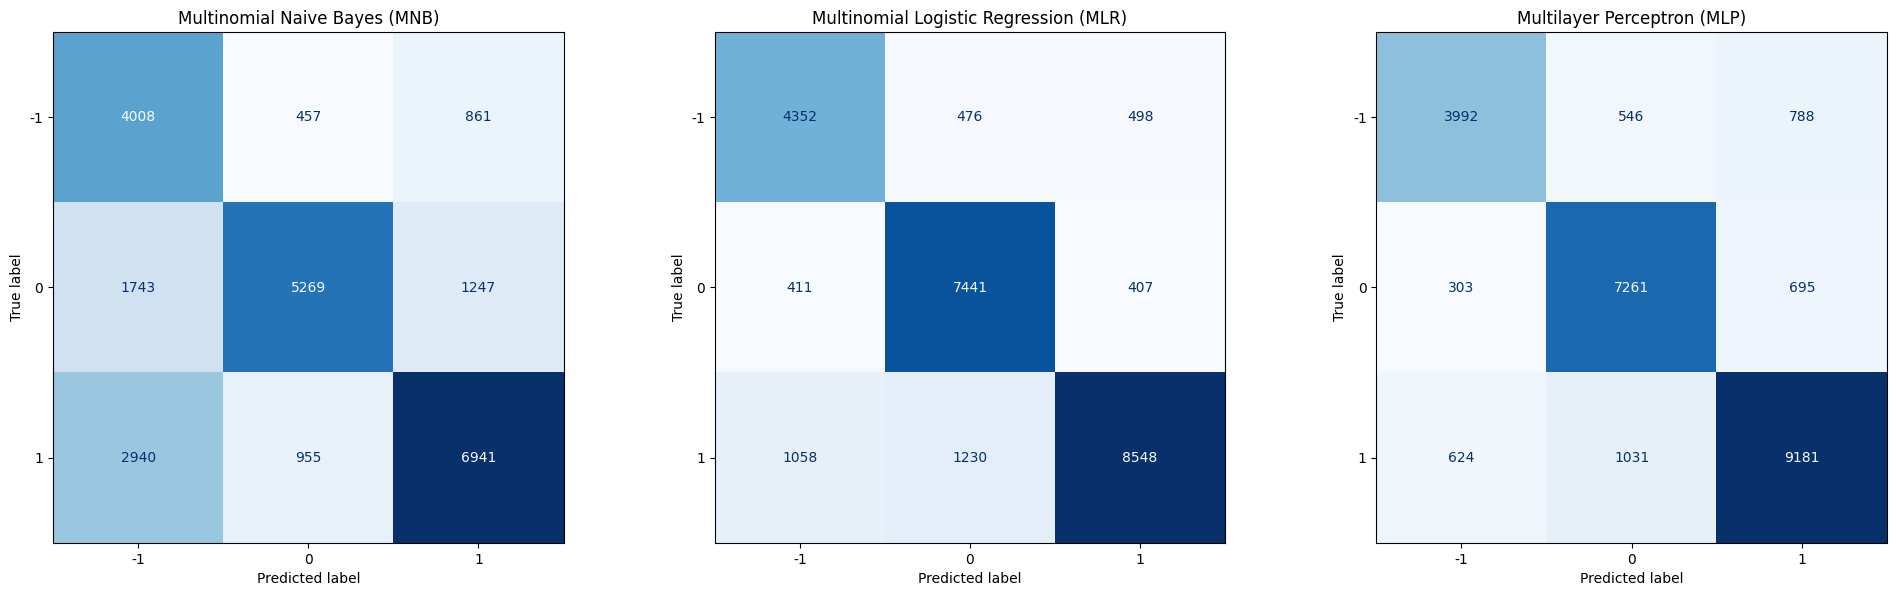

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, prediction) in enumerate(all_predictions_bal.items()):
    cm_values = confusion_matrix(y_test, prediction)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_values, display_labels=[-1, 0, 1])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)

    axes[i].set_title(name)

plt.tight_layout()
plt.show()

### **Recall and Precision**
### | Class `-1` |
#### **- Bayes**
The recall of Bayes **improved**. It went from **67.6%** to **75.3%** recall, so balancing may have helped "capture" more of this less-present class.

Although, as a consequence, its precision got **significantly worse**, with a **46.1%** precision compared to its previous **58.4%**.

#### **- LogReg**
Similar to Bayes, its recall **increased**, but its precision **decreased**, from **75.5%** to **81.7%** recall and **81.3%** to **74.8%** precision. Once again showing that the model is more open to classifying data as Class `-1`

#### **- MLP**
MLP's recall is **similar** to the imbalanced set, but its precision **improved slightly**, about **1.6%** higher than before, although it's mentioned in the respective notebook that results for this is **inconsistent**.


### | Class `0` |
#### **- Bayes**
The recall became **4.3% worse** compared to the imbalanced set's recall, but its precision **improved** by a tiny bit. The worsened recall may have been a trade-off to try and identify more Class `-1`s

#### **- LogReg**
Both its recall and precision got **slightly worse**, but compared to Bayes, its recall is still **significantly higher**. Seems like balancing did not really change much to this Class.

#### **- MLP**
It has a **slightly worse** recall but also a **slightly better** precision, although it's mentioned in the respective notebook that results for this is **inconsistent**.


### | Class `1` |
#### **- Bayes**
Its recall got **much worse** for Class `1` compared to before, being about **12% lower**. Its precision got **better**  by **2.4%**. Similar to Class `0`, the recall may have been a trade-off to try and identify more Class `-1`s`

#### **- LogReg**
Its recall got **worse**, but its precision got **better**. A possible trade-off for the benefit of Class `-1`.

#### **- MLP**
Its recall got **better**, but its precision got **worse**. Its performance is still **close to LogReg**.

Let's check out their confidence score for incorrect predictions.

E:\Media-Files\Real-Stuff\School\Code-Files\Cloned-Repositories\STINTSY-Order-of-Erin\.venv\Lib\site-packages\sklearn\naive_bayes.py:141: RuntimeWarning: invalid value encountered in subtract
  return jll - xpx.atleast_nd(log_prob_x, ndim=2).T


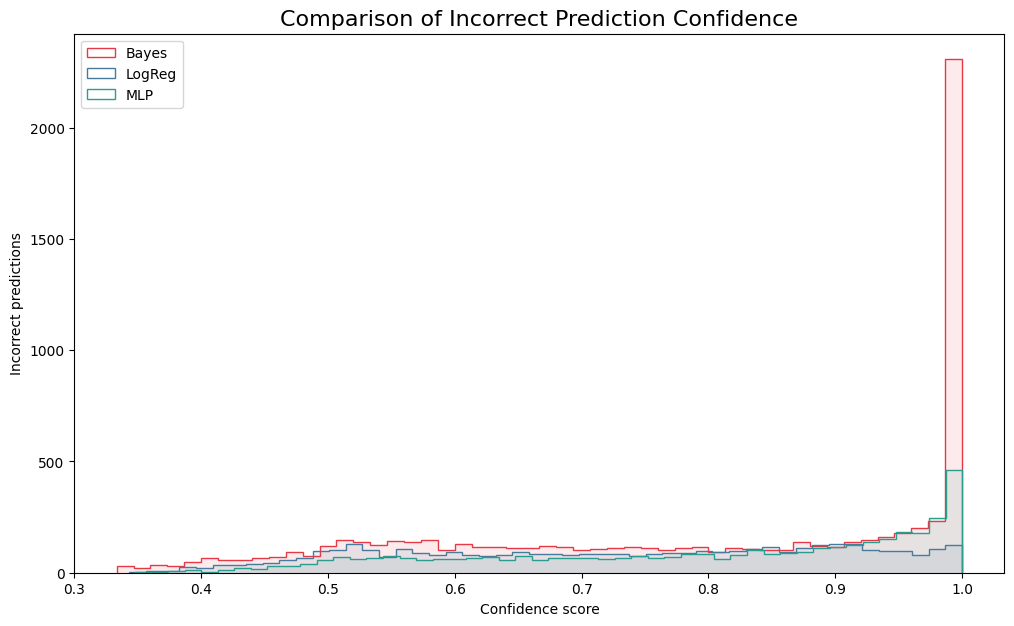

In [39]:
mnb_confidence = mnb_balanced.predict_proba(X_test).max(axis=1)[y_pred_mnb_bal != y_test.values]
mlr_confidence = mlr_balanced.predict_proba(X_test).max(axis=1)[y_pred_mlr_bal != y_test.values]

X_convert = []

for X_batch, _ in test_loader:
    X_convert.append(X_batch)

X_converted = torch.cat(X_convert, dim=0).to(DEVICE)

with torch.no_grad():
    mlp_logits = mlp_balanced(X_converted)
    mlp_probs = fun.softmax(mlp_logits, dim=1).cpu().numpy().max(axis=1)
    mlp_confidence = mlp_probs[y_pred_mlp_bal != y_test.values]

plt.figure(figsize=(12, 7))

# Outline
plt.hist(mnb_confidence, bins=50, histtype='step', label="Bayes", color="#E63946")
plt.hist(mlr_confidence, bins=50, histtype='step', label="LogReg", color="#457B9D")
plt.hist(mlp_confidence, bins=50, histtype='step', label="MLP", color="#2A9D8F")

# Fill
plt.hist(mnb_confidence, bins=50, alpha=0.1, color="#E63946")
plt.hist(mlr_confidence, bins=50, alpha=0.1, color="#457B9D")
plt.hist(mlp_confidence, bins=50, alpha=0.1, color="#2A9D8F")

plt.title("Comparison of Incorrect Prediction Confidence", fontsize=16)
plt.xlabel("Confidence score")
plt.ylabel("Incorrect predictions")
plt.legend(loc='upper left')

plt.show()

In this histogram, we can see that all **Bayes** and **MLP** are still **negatively skewed**. With Bayes' worse accuracy, the amount of incorrect predictions with 100% confidence went up. It seems like balancing did not have a large effect on improving this skew.

For **LogReg**, it lowered the quantity present at 100% confidence, shifting them to lower confidences. Though the quantity in **Bayes** is flattening the chart, **LogReg** is still relatively flat compared to both **MLP** and **LogReg**.

## **Balanced Data Insights**

Now, for balanced data, **MLP** performs the best, **LogReg** performs the second-best, and **Bayes** performs the worst. Balancing the training data seems to have made the models more "open" to classifying things as Class `-1`. This may improve reliability, but at the cost of lower precision and recall for the other two classes.

We'll next evaluate the hyperparameter-tuned models on our test data.

## **3.3 Comparison of Performance with Hyperparameter-tuned Models**

In this final evaluation, we'll now be comparing the models with **tuned hyperparameters**. Because MLP was slightly better with balanced compared to imbalanced data, the hyperparameters were found based on the balanced training set. The other two models, Bayes and LogReg, found their hyperparameters with imbalanced data as it performs better for them.

The process is the same as before. We'll get our models from the `models` folder  we saved them in.

In [40]:
mnb_tuned = jb.load('models/tuned/mnb_tuned.pkl')
mlr_tuned = jb.load('models/tuned/mlr_tuned.pkl')

neurons_in_hidden = 61
n_hidden_layers = 2
dropout = 0.44
batch_size = 32

mlp_tuned = MyLittlePony(
    vocab_size=TRAIN_BAL.vocab_size,
    neurons_in_hidden=neurons_in_hidden,
    n_hidden_layers=n_hidden_layers,
    dropout=dropout
).to(DEVICE)
mlp_tuned.load_state_dict(torch.load('models/tuned/mlp_tuned.pth'))
mlp_tuned.eval()

print("Models loaded")

Models loaded


In [41]:
y_pred_mnb_tun = mnb_tuned.predict(X_test)
y_pred_mlr_tun = mlr_tuned.predict(X_test)

# MLP
test_loader = DataLoader(TEST, batch_size=batch_size, shuffle=False)
y_pred, y_true = get_predictions(mlp_tuned, test_loader, DEVICE)

y_pred_mlp_tun = y_pred - 1  # labels to -1, 0, 1

We can also call the previous results again from imbalanced and balanced data for easier comparison.

In [42]:
all_predictions_tun = {
    "Multinomial Naive Bayes (MNB)": y_pred_mnb_tun,
    "Multinomial Logistic Regression (MLR)": y_pred_mlr_tun,
    "Multilayer Perceptron (MLP)": y_pred_mlp_tun
}

print("Accuracies on Imbalanced Data with Default Hyperparameters:")
for name, prediction in all_predictions_imbal.items():
    acc = accuracy_score(y_test, prediction)
    f1 = f1_score(y_test, prediction, average="macro")
    print(f"{name:37} Accuracy: {acc:.4f} | F1 score: {f1:.4f}")

print("\nAccuracies on Balanced Data with Default Hyperparameters:")
for name, prediction in all_predictions_bal.items():
    acc = accuracy_score(y_test, prediction)
    f1 = f1_score(y_test, prediction, average="macro")
    print(f"{name:37} Accuracy: {acc:.4f} | F1 score: {f1:.4f}")

print("\nAccuracies with Tuned Hyperparameters:")
for name, prediction in all_predictions_tun.items():
    acc = accuracy_score(y_test, prediction)
    f1 = f1_score(y_test, prediction, average="macro")
    print(f"{name:37} Accuracy: {acc:.4f} | F1 score: {f1:.4f}")

Accuracies on Imbalanced Data with Default Hyperparameters:
Multinomial Naive Bayes (MNB)         Accuracy: 0.7151 | F1 score: 0.7024
Multinomial Logistic Regression (MLR) Accuracy: 0.8441 | F1 score: 0.8346
Multilayer Perceptron (MLP)           Accuracy: 0.8344 | F1 score: 0.8255

Accuracies on Balanced Data with Default Hyperparameters:
Multinomial Naive Bayes (MNB)         Accuracy: 0.6641 | F1 score: 0.6584
Multinomial Logistic Regression (MLR) Accuracy: 0.8329 | F1 score: 0.8262
Multilayer Perceptron (MLP)           Accuracy: 0.8367 | F1 score: 0.8276

Accuracies with Tuned Hyperparameters:
Multinomial Naive Bayes (MNB)         Accuracy: 0.7265 | F1 score: 0.7175
Multinomial Logistic Regression (MLR) Accuracy: 0.8489 | F1 score: 0.8395
Multilayer Perceptron (MLP)           Accuracy: 0.8247 | F1 score: 0.8183


**LogReg** is back at the top with the **highest accuracy and F1 score**, with around 84.9% and 84% respectively. There is a **slight improvement** in performance compared to the imbalanced training set and.

**MLP** is back at **2nd**, being only **1% worse** than the balanced training set, but it's about **2% worse** compared to **tuned LogReg**.

**Bayes** still performs the **worst** but has a **small improvement** over imbalanced training set, being about 1.2% better in accuracy and 1.5% better in F1 score.

It looks like, in terms of accuracy and F1 score, hyperparameter tuning managed to make **Bayes** and **LogReg** perform **slightly better**, but made **MLP** perform **a bit worse**.

Let's check the precision, recall, and confusion matrices of the models.

We'll again include the ones for imbalanced (**Bayes** and **LogReg**) and balanced data (**MLP**). They'll be run in separate cells for easier readability and only the relevant sets will be shown with their respective models.

We'll first show the results of imbalanced data for the relevant models (**Bayes** and **LogReg**).

In [59]:
for separator in range(60):
    print("-", end='')
print("\nMultinomial Naive Bayes (MNB) [Imbalanced Data]")
report_classification_performance(model=None, y_pred=y_pred_mnb_imbal, y_test=y_test)
for separator in range(60):
    print("-", end='')
print("\nMultinomial Logistic Regression (MLR) [Imbalanced Data]")
report_classification_performance(model=None, y_pred=y_pred_mlr_imbal, y_test=y_test)

------------------------------------------------------------
Multinomial Naive Bayes (MNB) [Imbalanced Data]

Classification Report:

              precision    recall  f1-score   support

          -1     0.5837    0.6756    0.6263      5326
           0     0.7855    0.6811    0.7296      8259
           1     0.7426    0.7604    0.7514     10836

    accuracy                         0.7151     24421
   macro avg     0.7039    0.7057    0.7024     24421
weighted avg     0.7225    0.7151    0.7167     24421

------------------------------------------------------------
Multinomial Logistic Regression (MLR) [Imbalanced Data]

Classification Report:

              precision    recall  f1-score   support

          -1     0.8133    0.7550    0.7831      5326
           0     0.8195    0.9075    0.8612      8259
           1     0.8806    0.8395    0.8595     10836

    accuracy                         0.8441     24421
   macro avg     0.8378    0.8340    0.8346     24421
weighted avg     

array([ 0, -1,  0, ..., -1,  1,  0], shape=(24421,))

Then show the results of balanced data for the relevant models (**MLP**).

In [64]:
print("\nMultilayer Perceptron (MLP) [Balanced Data]")
report_classification_performance(model=None, y_pred=y_pred_mlp_bal, y_test=y_test)


Multilayer Perceptron (MLP) [Balanced Data]

Classification Report:

              precision    recall  f1-score   support

          -1     0.8115    0.7495    0.7793      5326
           0     0.8216    0.8792    0.8494      8259
           1     0.8609    0.8473    0.8540     10836

    accuracy                         0.8367     24421
   macro avg     0.8313    0.8253    0.8276     24421
weighted avg     0.8368    0.8367    0.8362     24421



array([ 0, -1,  0, ..., -1,  1,  0], shape=(24421,))

Finally, show the results of all three hyperparameter-tuned models.

In [63]:
for name, prediction in all_predictions_tun.items():
    for separator in range(60):
        print("-", end='')
    print(f"\n{name}", end='')
    report_classification_performance(model=None, y_pred=prediction, y_test=y_test)

------------------------------------------------------------
Multinomial Naive Bayes (MNB)
Classification Report:

              precision    recall  f1-score   support

          -1     0.6159    0.7223    0.6649      5326
           0     0.7568    0.7084    0.7318      8259
           1     0.7701    0.7422    0.7559     10836

    accuracy                         0.7265     24421
   macro avg     0.7143    0.7243    0.7175     24421
weighted avg     0.7320    0.7265    0.7279     24421

------------------------------------------------------------
Multinomial Logistic Regression (MLR)
Classification Report:

              precision    recall  f1-score   support

          -1     0.8309    0.7510    0.7890      5326
           0     0.8142    0.9234    0.8654      8259
           1     0.8892    0.8403    0.8641     10836

    accuracy                         0.8489     24421
   macro avg     0.8448    0.8382    0.8395     24421
weighted avg     0.8511    0.8489    0.8481     24421



### **Recall and Precision**
### | Class `-1` |
#### **- Bayes**
Both the recall and precision of Bayes **improved**. So the new hyperparameters helped "capture" more of this less-present class and also made the model identify the class more accurately.

#### **- LogReg**
**Minimal decrease** in recall alongside a **small increase** in precision, from **75.5%** to **75.1%** recall and **81.3%** to **83.1%** precision.

#### **- MLP**
A large recall **increase** but also a large precision **decrease**. This shows that the model became more open to classifying things as `-1`, but at the cost of precision.


### | Class `0` |
#### **- Bayes**
The recall **increased**, but its precision **decreased**. In terms of recall, a bit similar to Class `-1` where its captured more for being less represented compared to Class `1`.

#### **- LogReg**
Its recall **increased**, but its precision **marginally decreased**. So tuning helped in "capturing" more Class `0`s.

#### **- MLP**
**Slight increase** in recall and with a **small decrease** in precision. Similar to Class `-1`, the model became a bit more open in classifying data as Class `0`s.


### | Class `1` |
#### **- Bayes**
An **increase** in precision at a cost of **worse** recall. It seems like tuning made the model more inclusive with Class `-1` and `0` but made it miss out on some Class `1`s.

#### **- LogReg**

Had **nearly no difference** except for a **1% increase in precision**. Seems like the shift in identifying more Class `0`s helped in being more correct with Class `1`s.

#### **- MLP**
**Noticeably worse recall** for **increased** precision. Another trade-off for being more open to identifying Class `-1`.

Let's again check out their confidence score for incorrect predictions.

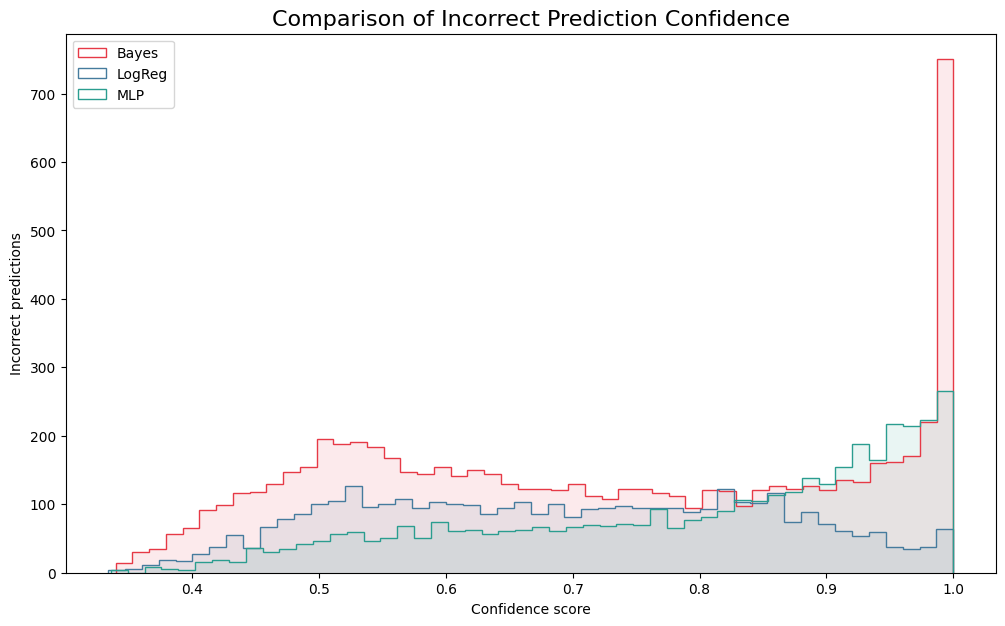

In [66]:
mnb_confidence = mnb_tuned.predict_proba(X_test).max(axis=1)[y_pred_mnb_imbal != y_test.values]
mlr_confidence = mlr_tuned.predict_proba(X_test).max(axis=1)[y_pred_mlr_imbal != y_test.values]

X_convert = []

for X_batch, _ in test_loader:
    X_convert.append(X_batch)

X_converted = torch.cat(X_convert, dim=0).to(DEVICE)

with torch.no_grad():
    mlp_logits = mlp_tuned(X_converted)
    mlp_probs = fun.softmax(mlp_logits, dim=1).cpu().numpy().max(axis=1)
    mlp_confidence = mlp_probs[y_pred_mlp_bal != y_test.values]

plt.figure(figsize=(12, 7))

# Outline
plt.hist(mnb_confidence, bins=50, histtype='step', label="Bayes", color="#E63946")
plt.hist(mlr_confidence, bins=50, histtype='step', label="LogReg", color="#457B9D")
plt.hist(mlp_confidence, bins=50, histtype='step', label="MLP", color="#2A9D8F")

# Fill
plt.hist(mnb_confidence, bins=50, alpha=0.1, color="#E63946")
plt.hist(mlr_confidence, bins=50, alpha=0.1, color="#457B9D")
plt.hist(mlp_confidence, bins=50, alpha=0.1, color="#2A9D8F")

plt.title("Comparison of Incorrect Prediction Confidence", fontsize=16)
plt.xlabel("Confidence score")
plt.ylabel("Incorrect predictions")
plt.legend(loc='upper left')

plt.show()

There is a significant improvement in the skew. While still being **negatively skewed** for **Bayes** and **MLP**, there are less incorrect predictions at 100% confidence, being instead shifted to lower confidences.

It looks like hyperparameter tuning somewhat increased the reliability of all three models, though high-confidence errors are still prominent in **Bayes** and **MLP**.

## **Hyperparameter-tuned Insights**

**LogReg** returns to be the best performer, while **MLP** moves back to being the second-best, and **Bayes** still performs the worst. Hyperparameter tuning increased reliability in identifying the less-present classes, proving its effectiveness.

# **4. Conclusion**

## **Overall Notebook Insights**

It may not have been worth doing undersampling to balance our data, as it did not help significantly improve performance in any of the models. This can possibly be attributed to our data proportions not being too significantly imbalanced.

Hyperparameter tuning definitely works, as in all three models, it lessened the quantity of incorrect predictions at 100% confidence.

## **The Best Model for Twitter Sentiment Analysis**

Throughout all tests, **Multinomial Naive Bayes** performed the **worst**, even with balancing and hyperparameter tuning. Our explanation for this is that its method in assuming independence is terrible in sentiment analysis, where word choices are absolutely dependent on one another.

Next is **Multilayer Perceptron**, where in most tests it performed well, having a close performance to **Multinomial Logistic Regression**. Though it has a close performance and hyperparameter tuning improved its reliability by making confidence in incorrect predictions less certain, its complexity and runtime are not worth it, as **LogReg** is better at both.

Overall, our best performer is **Multinomial Logistic Regression**, as its performance stayed consistently well with an acceptable accuracy and F1 score of about 80%. Together with its confidence not having a very negative skew compared to the other two models, and not being as complex to set up as **Multilayer Perceptron** and also having a much shorter runtime.